# Solución del laboratorio 7: Lenovo: comparar reglas con una solución de referencia
**Profesor de laboratorio: Manuel López.** Material docente.
Los resultados guardados corresponden a la ejecución del mismo código en Python. Abra el notebook desde esta carpeta para conservar las rutas relativas.
El desarrollo matemático, la interpretación y la pauta de corrección están en el archivo .tex asociado.


enumeracion_base
  secuencia  tardanza  makespan
A-B-C-D-E-F      46.0      30.0
A-B-C-D-F-E      44.0      28.0
A-B-C-E-D-F      37.0      26.0
A-B-C-E-F-D      38.0      26.0
A-B-C-F-D-E      45.0      28.0
A-B-C-F-E-D      48.0      30.0
A-B-D-C-E-F      32.0      26.0
A-B-D-C-F-E      38.0      28.0
A-B-D-E-C-F      29.0      26.0
A-B-D-E-F-C      32.0      28.0
A-B-D-F-C-E      30.0      24.0
A-B-D-F-E-C      27.0      24.0
Vista inicial: 720 filas completas en enumeracion_base.csv

detalle_base_SPT
trabajo  inicio_preparacion  preparacion  inicio  terminacion  fecha  tardanza
      B                   0            0       0            2      4         0
      E                   2            2       4            6     15         0
      D                   6            2       8           11      7         4
      A                  11            2      13           17      6        11
      F                  17            2      19           23     16         7
      C        

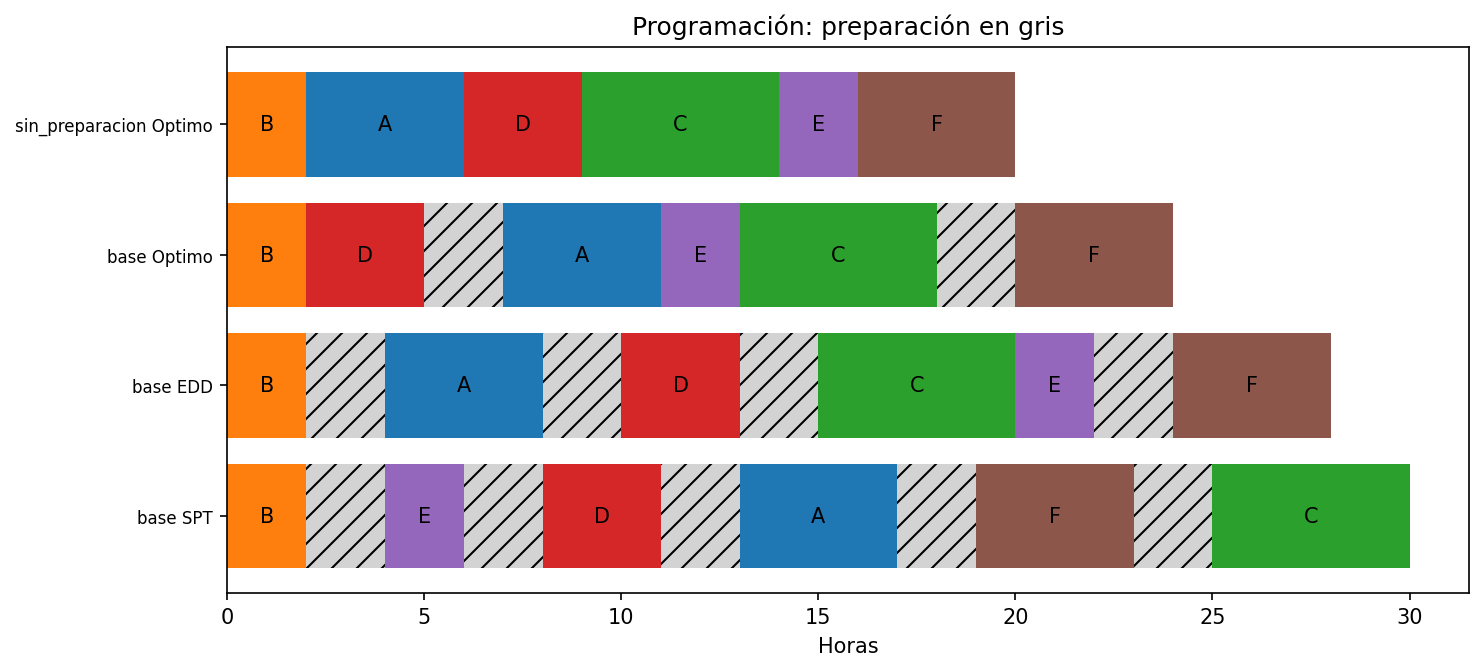

In [1]:
"""Solución docente de Gestión de Operaciones. Profesor: Manuel López."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
datos = base / "datos"
salida = base / "resultados"
salida.mkdir(exist_ok=True)
parametros = json.loads((datos / "parametros.json").read_text(encoding="utf-8"))

def tabla(df, nombre):
    df.to_csv(salida / (nombre + ".csv"), index=False)
    visible = df if len(df) <= 28 else df.head(12)
    print("\n" + nombre + "\n" + visible.to_string(index=False))
    if len(df) > 28:
        print(f"Vista inicial: {len(df)} filas completas en {nombre}.csv")

def figura(fig, nombre):
    fig.tight_layout()
    fig.savefig(salida / (nombre + ".png"), dpi=150, bbox_inches="tight")
    if "__file__" not in globals():
        plt.show()
    plt.close(fig)

def resumen(obj):
    def convertir(x):
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, np.generic):
            return x.item()
        raise TypeError(type(x))
    (salida / "resumen.json").write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=convertir),
        encoding="utf-8")

from itertools import permutations
trab=pd.read_csv(datos / "trabajos.csv").set_index("trabajo")
pre=pd.read_csv(datos / "preparaciones.csv")
setup=pre.set_index(["familia_origen","familia_destino"]).preparacion_h.to_dict()
assert trab.index.is_unique and (trab.liberacion_h==0).all()

def evaluar(secuencia,sin_preparacion=False):
    assert len(secuencia)==len(trab) and set(secuencia)==set(trab.index)
    reloj=parametros["tiempo_inicial_h"]; anterior=None; filas=[]
    for j in secuencia:
        f=trab.loc[j,"familia"]
        s=parametros["preparacion_inicial_h"] if anterior is None else setup[anterior,f]
        if sin_preparacion:
            s=0
        inicio_preparacion=reloj; inicio=reloj+s
        reloj=inicio+trab.loc[j,"procesamiento_h"]
        filas.append({"trabajo":j,"inicio_preparacion":inicio_preparacion,
                      "preparacion":s,"inicio":inicio,"terminacion":reloj,
                      "fecha":trab.loc[j,"fecha_entrega_h"],
                      "tardanza":max(reloj-trab.loc[j,"fecha_entrega_h"],0)})
        anterior=f
    t=pd.DataFrame(filas)
    clave=(float(t.tardanza.sum()),float(reloj),tuple(secuencia))
    return clave,t

ids=sorted(trab.index)
spt=sorted(ids,key=lambda j:(trab.loc[j,"procesamiento_h"],j))
edd=sorted(ids,key=lambda j:(trab.loc[j,"fecha_entrega_h"],j))
perms=list(permutations(ids)); assert len(perms)==720
res={}; metricas=[]; graficos=[]
for sin in [False,True]:
    etiqueta="sin_preparacion" if sin else "base"
    evaluadas=[evaluar(s,sin)[0] for s in perms]
    mejor=min(evaluadas)
    tabla(pd.DataFrame([{"secuencia":"-".join(c[2]),"tardanza":c[0],
                         "makespan":c[1]} for c in evaluadas]),"enumeracion_"+etiqueta)
    res[etiqueta]={"secuencia":mejor[2],"tardanza":mejor[0],"makespan":mejor[1]}
    for nombre,seq in [("SPT",spt),("EDD",edd),("Optimo",mejor[2])]:
        clave,t=evaluar(seq,sin)
        tabla(t,"detalle_"+etiqueta+"_"+nombre)
        metricas.append({"escenario":etiqueta,"regla":nombre,"secuencia":"-".join(seq),
                         "tardanza":clave[0],"makespan":clave[1],
                         "preparacion":float(t.preparacion.sum())})
        if not sin or nombre=="Optimo":
            graficos.append((etiqueta+" "+nombre,t))
tabla(pd.DataFrame(metricas),"comparacion")
fig,ax=plt.subplots(figsize=(10,4.6)); colors=plt.get_cmap("tab10")
for pos,(nombre,t) in enumerate(graficos):
    for r in t.itertuples():
        if r.preparacion:
            ax.barh(pos,r.preparacion,left=r.inicio_preparacion,color="lightgray",hatch="//")
        ax.barh(pos,r.terminacion-r.inicio,left=r.inicio,color=colors(ids.index(r.trabajo)))
        ax.text((r.inicio+r.terminacion)/2,pos,r.trabajo,ha="center",va="center")
ax.set_yticks(range(len(graficos)),[x[0] for x in graficos],fontsize=8)
ax.set(xlabel="Horas",title="Programación: preparación en gris")
figura(fig,"gantt")
assert res["base"]=={"secuencia":("B","D","A","E","C","F"),"tardanza":22.,"makespan":24.}
resumen({"optimos":res,"comparacion":metricas})
